In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../../Data Capsule/ROUND_1/trades_round_1_day_0.csv", sep=";")

# print(df.columns)
# print(df.head())
osmium = df[df["symbol"] == "ASH_COATED_OSMIUM"].copy()
osmium = osmium.sort_values("timestamp")

prices = pd.read_csv("../../../Data Capsule/ROUND_1/prices_round_1_day_0.csv", sep=";")
prices = prices[prices["product"] == "ASH_COATED_OSMIUM"].copy()
prices = prices.sort_values("timestamp")

df = df.merge(prices[["timestamp", "mid_price"]], on="timestamp", how="left")
df["mid_price"] = df["mid_price"].ffill()


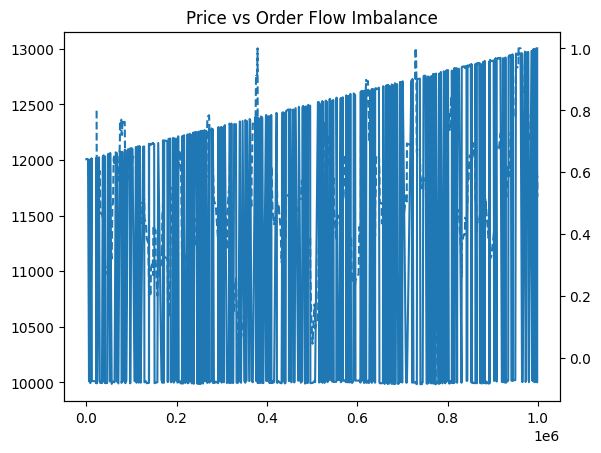

In [6]:
# PLOT 1 ORDER FLOW IMBALANCE VS PRICE
# classify aggression
df["buy_volume"] = np.where(df["price"] >= df["mid_price"], df["quantity"], 0)
df["sell_volume"] = np.where(df["price"] < df["mid_price"], df["quantity"], 0)

# rolling imbalance
window = 20
df["buy_rolling"] = df["buy_volume"].rolling(window).sum()
df["sell_rolling"] = df["sell_volume"].rolling(window).sum()

df["imbalance"] = (df["buy_rolling"] - df["sell_rolling"]) / (
    df["buy_rolling"] + df["sell_rolling"] + 1e-9
)

# plot
fig, ax1 = plt.subplots()
ax1.plot(df["timestamp"], df["price"], label="Price")
ax2 = ax1.twinx()
ax2.plot(df["timestamp"], df["imbalance"], linestyle="dashed", label="Imbalance")

ax1.set_title("Price vs Order Flow Imbalance")
plt.show()